In [59]:
import tensorflow as tf

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [61]:
dataset = pd.read_csv("Churn_Modelling.csv")
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [62]:
#get the dependent and independent features
x = dataset.iloc[:,3:13]
y = dataset.iloc[:,13]

In [63]:
#feature engineering
from sklearn.preprocessing import OneHotEncoder #break the multi class 

In [64]:
geo = pd.get_dummies(x["Geography"]) # get_dummies automatically applies ohw
geo

,France,Germany,Spain
0,True,False,False
1,False,False,True
2,True,False,False
3,True,False,False
4,False,False,True
...,...,...,...
9995,True,False,False
9996,True,False,False
9997,True,False,False
9998,False,True,False


In [65]:
gender = pd.get_dummies(x["Gender"]) # get_dummies automatically applies ohw
gender


,Female,Male
0,True,False
1,True,False
2,True,False
3,True,False
4,True,False
...,...,...
9995,False,True
9996,False,True
9997,True,False
9998,False,True


In [66]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [67]:
#Concatenate these variable with dataframe
x = x.drop(["Geography","Gender"],axis=1) 
x.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [68]:
x =pd.concat([x,geo,gender],axis=1)
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,Female,Male
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,True,False,False,True,False
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True,True,False


In [69]:
#Make the train test split
from sklearn.model_selection import train_test_split as tts

In [70]:
x_train,x_test,y_train,y_test= tts(x,y,test_size=0.34,random_state=23)

In [71]:
x_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,Female,Male
8037,547,62,10,127738.75,2,1,1,85153.00,True,False,False,False,True
2190,700,59,5,137648.41,1,1,0,142977.05,False,True,False,True,False
2462,672,53,9,169406.33,4,1,1,147311.47,True,False,False,True,False
7517,586,58,7,151933.63,1,1,0,162960.05,True,False,False,False,True
8280,706,53,7,0.00,2,0,1,117939.17,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,643,59,3,170331.37,1,1,1,32171.79,False,True,False,False,True
6175,503,31,4,0.00,2,1,1,21645.06,False,False,True,False,True
9704,625,22,9,0.00,2,1,0,157072.91,True,False,False,False,True
9256,765,37,7,102708.77,1,1,0,9087.81,False,True,False,False,True


In [ ]:
#features scaling : Should be applied in algorithms that 
# require distance calculation or Gradient descent 
# like ann,linear regression, knn,kmeans
from sklearn.preprocessing import StandardScaler #used of ANN

In [74]:
sc  = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [75]:
x_train

array([[-1.06344643,  2.1892192 ,  1.72165001, ..., -0.58254148,
        -0.92111855,  0.92111855],
       [ 0.51527918,  1.90344858, -0.00933826, ..., -0.58254148,
         1.08563659, -1.08563659],
       [ 0.22636208,  1.33190734,  1.37545236, ..., -0.58254148,
         1.08563659, -1.08563659],
       ...,
       [-0.25860592, -1.62105576,  1.37545236, ..., -0.58254148,
        -0.92111855,  0.92111855],
       [ 1.18597961, -0.19220265,  0.68305705, ..., -0.58254148,
        -0.92111855,  0.92111855],
       [ 0.40177604,  3.23704482, -1.39412888, ...,  1.71661595,
        -0.92111855,  0.92111855]])

In [76]:
x_train.shape

(6599, 13)

In [77]:
#Creating the ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import ReLU,LeakyReLU,ELU,PReLU
from tensorflow.keras.layers import Dropout


In [80]:
# Initialize ANN

classifier = Sequential() #this take the entire neural network as a whole allowing f,b propagation

In [84]:
#add the input layer
#Dense allows additoin of layers by stating how many neurons are needed for it along with the type pf activation function that would be used by it
classifier.add(Dense(units = 13,activation= "relu"))  #for input layer units = no of rows later we change it as needed


In [ ]:
# add the first hidden layer 
classifier.add(Dense(units=7,activation= "relu")) # for 1st hl no of neurons = 7 

In [87]:
#add the second hidden layer
classifier.add(Dense(units= 6,activation= "relu" )) #for 2nd layer no of neurons = 6

In [88]:
#adding the output layer
classifier.add(Dense(units= 1 ,activation="sigmoid")) # for binary classifier sigmoid

In [89]:
#Train the neural network

classifier.compile(optimizer="adam", loss = "binary_crossentropy",metrics= ["accuracy"])

2026-05-18 20:57:33.485142: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-05-18 20:57:33.485209: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-05-18 20:57:33.485226: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: anshuman-Aspire-A715-41G
2026-05-18 20:57:33.485234: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] hostname: anshuman-Aspire-A715-41G
2026-05-18 20:57:33.485535: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:197] libcuda reported version is: 535.288.1
2026-05-18 20:57:33.485583: I external/local_xla/xla/stream_executor/cuda/cuda_diagno

In [91]:
#manually assigning learnimg rate
import tensorflow
opt = tensorflow.keras.optimizers.Adam(learning_rate = 0.01) # default value

In [ ]:
# Training the model without early stop and on high epoch leads to wasted epochs and stagnated accuracy 

# model_history = classifier.fit(x_train,y_train,validation_split=0.33,batch_size=10,epochs=1000)

In [93]:
#plotting the model working 

model_history = classifier.fit(x_train,y_train,validation_split=0.33,batch_size=10,epochs=50)

Epoch 1/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8690 - loss: 0.3135 - val_accuracy: 0.8595 - val_loss: 0.3576
Epoch 2/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8748 - loss: 0.2969 - val_accuracy: 0.8531 - val_loss: 0.3583
Epoch 3/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8760 - loss: 0.2962 - val_accuracy: 0.8512 - val_loss: 0.3612
Epoch 4/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8795 - loss: 0.2958 - val_accuracy: 0.8563 - val_loss: 0.3579
Epoch 5/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8762 - loss: 0.3028 - val_accuracy: 0.8572 - val_loss: 0.3587
Epoch 6/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8739 - loss: 0.3064 - val_accuracy: 0.8577 - val_loss: 0.3515
Epoch 7/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8746 - loss: 0.3003 - val_accuracy: 0.8572 - val_loss: 0.3583
Epoch 8/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8804 - loss: 0.2922 - val_accuracy: 0.

In [95]:
#applying early stopping
import tensorflow as tf
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor= "val_loss",
    min_delta = 0.0001,
    patience= 20,
    verbose= 1 ,
    mode = "auto",
    baseline= None,
    restore_best_weights= False
)

In [ ]:
#Redoing the mmodel_history but this time with early stopping
#stops the epochs at 25

model_history = classifier.fit(x_train,y_train,validation_split=0.33,batch_size=10,epochs=50,callbacks=early_stopping)

Epoch 1/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8873 - loss: 0.2799 - val_accuracy: 0.8480 - val_loss: 0.3776
Epoch 2/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8807 - loss: 0.2807 - val_accuracy: 0.8476 - val_loss: 0.3780
Epoch 3/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8841 - loss: 0.2851 - val_accuracy: 0.8434 - val_loss: 0.3897
Epoch 4/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8811 - loss: 0.2778 - val_accuracy: 0.8499 - val_loss: 0.3767
Epoch 5/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8666 - loss: 0.2989 - val_accuracy: 0.8489 - val_loss: 0.3761
Epoch 6/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8827 - loss: 0.2739 - val_accuracy: 0.8421 - val_loss: 0.3779
Epoch 7/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8828 - loss: 0.2870 - val_accuracy: 0.8499 - val_loss: 0.3794
Epoch 8/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8819 - loss: 0.2914 - val_accuracy: 0.

In [98]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

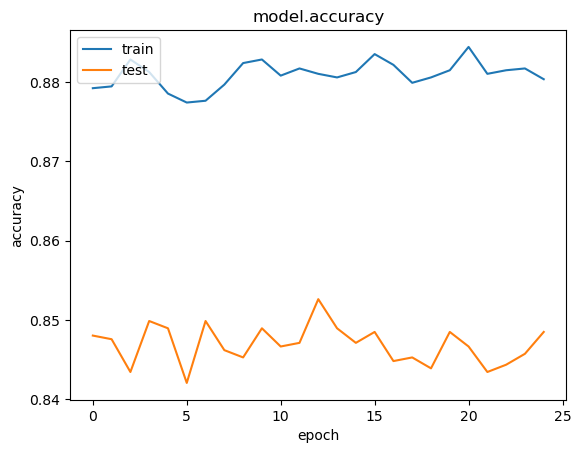

In [100]:
#summarize the history for accuracy 
plt.plot(model_history.history["accuracy"])
plt.plot(model_history.history["val_accuracy"])

plt.title("model.accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train","test"], loc = "upper left")
plt.show()

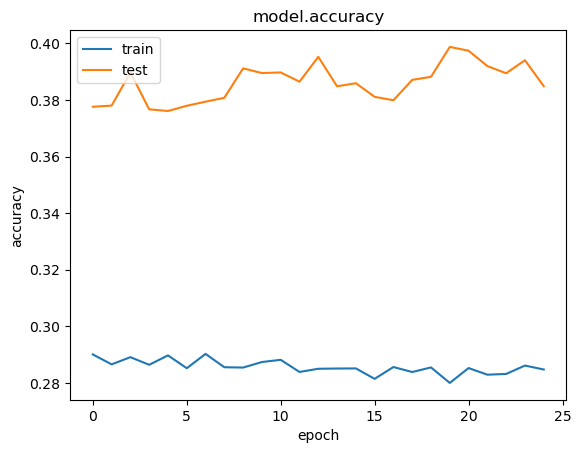

In [101]:
#summarize the history for loss 
plt.plot(model_history.history["loss"])
plt.plot(model_history.history["val_loss"])

plt.title("model.accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train","test"], loc = "upper left")
plt.show()

In [ ]:
# Making Prediction and evaluating the model
y_pred = classifier.predict(x_test)

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [103]:
y_pred = (y_pred >= 0.5)

In [108]:
#make the confusion matric
from sklearn.metrics import confusion_matrix,accuracy_score


In [107]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[2570,  145],
       [ 360,  326]])

In [110]:
score = accuracy_score(y_pred,y_test)
score

0.8515142605116143

In [112]:
#get the weights 
classifier.get_weights()

[array([[-0.23006555,  0.0807452 ,  0.55361706, -0.16955972, -0.10094849,
          0.27738014, -0.46587938, -0.09242607, -0.09577468, -0.45593682,
          0.31753874,  0.22107288,  0.03563892],
        [ 0.25114477,  1.4578904 ,  0.4352451 , -0.12177442, -0.16899094,
         -1.1004101 ,  0.79773694,  0.5276012 , -0.12779629, -0.21852377,
          0.13894117, -0.3303566 ,  0.5802694 ],
        [-0.04975449, -0.00996265,  0.45953992, -0.6037687 ,  0.1910645 ,
         -0.3769133 , -0.21132869, -0.07913639, -0.14349562, -0.05354008,
          0.61801326, -0.33695862,  0.2697667 ],
        [-0.48878834, -0.51706195, -0.12886915, -0.16890557, -0.2331571 ,
         -0.19346908,  0.97519666, -0.0443874 , -0.98581946, -0.39224964,
          0.27088305, -0.3944643 , -0.8565724 ],
        [ 0.74689597, -0.5793287 ,  0.2281038 ,  0.21399854, -0.27746472,
         -0.08797438,  0.43800023, -1.1585642 , -0.25525212, -0.45913354,
          0.6297223 ,  0.6095652 , -0.3590843 ],
        [ 0.021